# Cell typing – updated to match IHOPE project

# Prep

In [1]:
import pandas as pd
from anndata import AnnData, read_h5ad
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import math

Make sure you're in the parent directory:

In [2]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Preprocessing

**If it's the first time running the sample:**

Load, filter and normalize your raw data in csv format. Also, make sure to specify which file you're working with to facilitate later analysis. All subsequent naming of files is based on this.


In [18]:
from scripts import preprocessing

# Input path, here you need to write the entire raw data file name
csv_in = "../data/raw/IHOPE39_MesLN_B.csv"

# Keep track of which sample you're working on:
basename = "IHOPE39_MesLN_B"

# Output path, you can use this default format based on your basename:
csv_out = f"../data/processed/{basename}_cleaned_raw.csv"

# Clean raw CSV
preprocessing.clean_cell_columns(csv_in, csv_out)

Cleaned CSV saved to: ../data/processed/IHOPE39_MesLN_B_cleaned_raw.csv


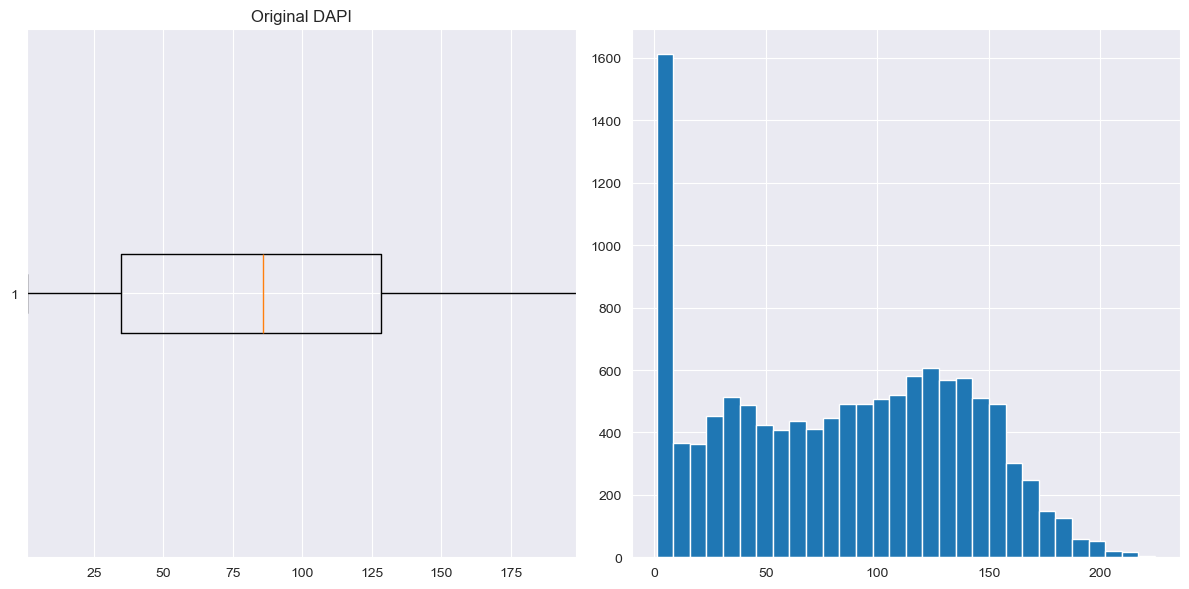

Filtered data saved to: ../data/processed/IHOPE39_MesLN_B_cleaned_filtered.csv


In [20]:
from scripts import preprocessing

# Run preprocessing
input_file = f"../data/processed/{basename}_cleaned_raw.csv"
output_file = f"../data/processed/{basename}_cleaned_filtered.csv"

preprocessing.preprocess(input_file, output_file, plot=True)


For really large files, use this version where the file is loaded in chunks:

In [ ]:
from scripts import preprocessing

# Marker intensity columns
TARGET_COLUMNS = [
    "CCR6: Mean", "CCR7: Mean", "CD107a: Mean", "CD11c: Mean", "CD14: Mean", "CD141: Mean",
    "CD163: Mean", "CD1c: Mean", "CD20: Mean", "CD21: Mean", "CD27: Mean", "CD31: Mean",
    "CD34: Mean", "CD38: Mean", "CD3e: Mean", "CD4: Mean", "CD40: Mean", "CD45: Mean",
    "CD45RA: Mean", "CD45RO: Mean", "CD57: Mean", "CD68: Mean", "CD69: Mean", "CD79a: Mean",
    "CD8: Mean", "Collagen IV: Mean", "CXCL13: Mean", "DAPI: Mean", "FOXP3: Mean",
    "Granzyme B: Mean", "HLA-DR: Mean", "ICOS: Mean", "IFNG: Mean", "Ki67: Mean", "LYVE1: Mean",
    "PD-1: Mean", "TCF-1: Mean", "Vimentin: Mean"
]

OBS_COLUMNS = [
    "Object ID",
    "Centroid X µm",
    "Centroid Y µm",
    "Area µm^2",
    "Nucleus/Cell area ratio"
]

csv_in = "../data/raw/IHOPE14_Spleen_RAW_RESULTS_combined.csv"

basename = "IHOPE14_Spleen"

csv_out = f"../data/processed/{basename}_cleaned_filtered.csv"

preprocessing.extract_and_filter_columns_chunked(
    csv_in,
    csv_out,
    TARGET_COLUMNS,
    OBS_COLUMNS
)

**Normalize**

Choose between: "arcsinh", "zscore" and "none".

For arcsinh, you can specify a cofactor.

In [11]:
from scripts.transforms import apply_transform

method = "arcsinh"
cofactor = 5.0    # Comment out if not applying arcsinh
input_file = f"../data/processed/{basename}_cleaned_filtered.csv"
output_file = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"

df_out, markers, metadata, fig = apply_transform(
    input_file=input_file,
    method=method,
    cofactor=cofactor, # Comment out if not applying arcsinh
    output_file=output_file,
    save_plot=True
)

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/IHOPE39_MesLN_A_cleaned_filtered.csv'

# Building Anndata and annotating marker positivity


In [ ]:
from scripts.anndata_helpers import load_and_build_anndata, save_h5ad

# Read file and create AnnData object
filename = f"../data/processed/{basename}_cleaned_filtered_arcsinh_cf5.0.csv"
adata = load_and_build_anndata(filename)

Quick overview:

In [ ]:
print("adata summary: ")
print(adata)
print("adata X shape: ")
print(adata.X.shape)
print("adata spatial data dimensions: ")
print(adata.obsm['spatial'].shape)
print("adata var: ")
print(adata.var)
print("adata var names: ")
print(adata.var_names)
print("adata obs columns: ")
print(adata.obs.columns)

**Apply marker positivity thresholds (GMM intersections)**

Detect if the distribution is uni- or multimodal and assign positive/negative identity for each marker to each cell. If unimodal, a quantile fallback is used. You can change the quantile argument if needed.

In [ ]:
from scripts.annotation import compute_positivity_matrix

# Annotate all cells with GMM-based positivity for canonical markers, fallback to percentile if unimodal
adata, thresholds, best_gmms = compute_positivity_matrix(
    adata,
    quantile=0.8,
    random_state=0
)

In [ ]:
# Visualize the distributions and thresholds:
from scripts.annotation import plot_marker_gmm_adata
plot_marker_gmm_adata(adata,
                      thresholds,
                      best_gmms,
                      title_prefix=f"{basename} Marker: ",
                      save=False,
                      filename=f"{basename}_GMM_histograms")

In [ ]:
print(f"{basename}_GMM_thresholds")

Save anndata object with progress so far

In [ ]:
# Save AnnData as h5ad
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
save_h5ad(adata, h5adpath)

# OPTIONAL:

**If you wish to run spatially informed cell typing, switch to the notebook rulebased_celltyping_with_banksy.ipynb and use the latest saved version of your AnnData.**

# Rule-based cell typing

Each cell type will correspond to a column in the AnnData object, with a boolean True/False for every cell type in every cell.

On the lineage ("type") level, the labels are exclusive.

On the intermediate and subtype levels, labels may overlap.

If you want to clean up before you rerun cell type assignment:

In [ ]:
#If you want to load AnnData from an existing H5AD file:
import anndata as ad

basename = "IHOPE26_Spleen"
adata = ad.read_h5ad(
    f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM.h5ad"
)

**Cell typing:**

In [ ]:
from scripts.celltype_rules_IHOPE import assign_cell_types_bool_IHOPE

adata = assign_cell_types_bool_IHOPE(adata)

Save anndata with cell type information:

In [ ]:
h5adpath = f"../data/processed/anndata/{basename}_filtered_arcsinh_cf5_GMM_IHOPE_celltypes.h5ad"
save_h5ad(adata, h5adpath)

# Visual diagnostics

**FACS-style plots**

To explore the thresholds

In [ ]:
from scripts.marker_plots import plot_marker_axes

plot_marker_axes(
    adata,
    x_marker="CD79a",
    y_marker="CD20",
    base_mask="type_B",
    title=f"B cells: CD45 vs CD20",
    show_thresholds = True
)

In [ ]:
plot_marker_axes(
    adata,
    x_marker="CD45",
    y_marker="CD3e",
    base_mask="type_T",
    title="T cells: CD45 vs CD3e"
)

**Marker spatial plots**

To visualize marker-positive cells in the tissue

In [ ]:
from scripts.spatialmapping import plot_spatial_marker

# One marker
plot_spatial_marker(adata, "CD20", thresholded=True, title_prefix="GMM thresholding: ", color_hi="red", color_lo="lightblue")

plot_spatial_marker(adata, "CD79a", thresholded=True, title_prefix="GMM thresholding: ", color_hi="red", color_lo="lightblue")

**Heatmap of markers in cell types**

To explore co-expression of markers

In [ ]:
from scripts.marker_heatmap import clustered_marker_heatmap

# All cell type columns
celltype_cols = [
    c for c in adata.obs.columns
    if c.startswith(("type_", "intermediate_", "subtype_"))
]

matrix = clustered_marker_heatmap(
    adata,
    celltype_cols=celltype_cols,
    min_cells=15,
    base_fig_width=10,
    fig_height=12,
    cmap="viridis",
)


# Spatial visualization

In [ ]:
from scripts.spatial_celltypes import spatial_celltype_plot

# You can select level and choose to include or exclude cell types:
celltype_cols = [c for c in adata.obs.columns if c.startswith("type_") and not c.endswith("unclassified") and not c.endswith("Endothelial")]

# Or use this for all cell types:
#[c for c in adata.obs.columns if c.startswith(("type_", "intermediate_", "subtype_"))]

# Spatial plot
spatial_celltype_plot(adata, celltype_cols, min_cells=50)


In [ ]:
print(f"{basename}_types_spatial")

In [ ]:
from scripts.spatial_celltypes import spatial_celltype_plot

# T cell subtype columns
t_subtypes = [c for c in adata.obs.columns if c.startswith("subtype_T")]

# Plot
spatial_celltype_plot(
    adata,
    celltype_cols=t_subtypes,
    min_cells=15,
    size=10,
    alpha=0.7
)

In [ ]:
print(f"{basename}_Tc_types_spatial")

In [ ]:
from scripts.spatial_celltypes import spatial_celltype_plot

# B cell subtype columns
b_subtypes = [c for c in adata.obs.columns if c.startswith("subtype_B_")]

# Plot
spatial_celltype_plot(
    adata,
    celltype_cols=b_subtypes,
    min_cells=15,
    size=10,
    alpha=0.7
)


In [ ]:
print(f"{basename}_Bc_types_spatial")

In [ ]:
celltypes = (
    [c for c in adata.obs.columns if c.startswith("type_")] +
    [c for c in adata.obs.columns if c.startswith("intermediate_")] +
    [c for c in adata.obs.columns if c.startswith("subtype_")]
)

# Filter by min_cells if desired
celltypes = [c for c in celltypes if adata.obs[c].sum() >= 15]

n = len(celltypes)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))

axes = axes.flatten()

for ax, ct in zip(axes, celltypes):

    mask = adata.obs[ct].astype(bool)

    ax.scatter(
        adata.obs.loc[mask, "x"],
        adata.obs.loc[mask, "y"],
        s=8,
        alpha=0.7
    )

    ax.set_title(ct, fontsize=10)
    ax.invert_yaxis()
    ax.axis("off")

# Remove empty panels
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print(f"{basename}_celltypes_spatial_grid")


# Cell type summary in sample

Use after loading data and running annotation!

This will be used later for statistical comparison between tissues.

In [ ]:
from scripts.summary_celltypes_IHOPE import summarize_celltypes_IHOPE

df_summary = summarize_celltypes_IHOPE(
    adata,
    filename=f"{basename}_filtered_arcsinh_cf5.0_IHOPE_summary.csv"
)
